[Dataset Reference: Urban Sound Tagging with Spatiotemporal Context](https://dcase.community/challenge2020/task-urban-sound-tagging-with-spatiotemporal-context)

In [1]:
# ---------- INITIALIZE ----------
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/dl4m/final-project
%load_ext autoreload
%autoreload 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/dl4m/final-project


In [2]:
# ---------- IMPORTS ----------
import utils as u

import IPython.display as ipd
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import torch
import torchaudio

In [3]:
# ---------- DEFINE DATA PATH ----------
data_home = '/content/drive/MyDrive/dl4m/final-project/SONYC'

# ---------- LOAD ANNOTATIONS ----------
annotations_path = os.path.join(data_home, 'annotations.csv')
annotations_df = pd.read_csv(annotations_path)

# ---------- LOAD AUDIO FILES AND LABELS ----------
if os.path.exists(data_home):
    audio_dir = os.path.join(data_home, 'audio')

    if not os.path.exists(audio_dir):
        print("Extract the audio files with script (unpack_audio.sh)")

    else:
        # You must have imported your utilities module as u before this
        # Section Title (for fun)
        print("-" * 80)
        title = f"AUDIO FILES AND LABELS"
        print("\n" + title.center(80) + "\n")

        # Audio files
        audio_files, labels = u.load_data(audio_dir)
        print("-" * 80)
        print("Total number of audio files:", len(audio_files))
        print("-" * 80)
        print("\nSample audio files:")
        print("-" * 80)
        print(audio_files[:5])

        # Annotations
        print("\nSample annotations:")
        print("-" * 80)  # horizontal separator
        print(annotations_df.head())

else:
    print('Data directory not found.')

--------------------------------------------------------------------------------

                             AUDIO FILES AND LABELS                             

--------------------------------------------------------------------------------
Total number of audio files: 18528
--------------------------------------------------------------------------------

Sample audio files:
--------------------------------------------------------------------------------
['/content/drive/MyDrive/dl4m/final-project/SONYC/audio/32_013690.wav', '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/02_002507.wav', '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/01_002247.wav', '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/39_007821.wav', '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/01_008226.wav']

Sample annotations:
--------------------------------------------------------------------------------
  split  sensor_id audio_filename  annotator_id  borough  block  latitude  \
0 

Train sensors   : {1, 2, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45}
Validate sensors: {0, 3, 4, 5, 6, 7, 9, 10, 46}
Test sensors    : {0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 22, 23, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 61}


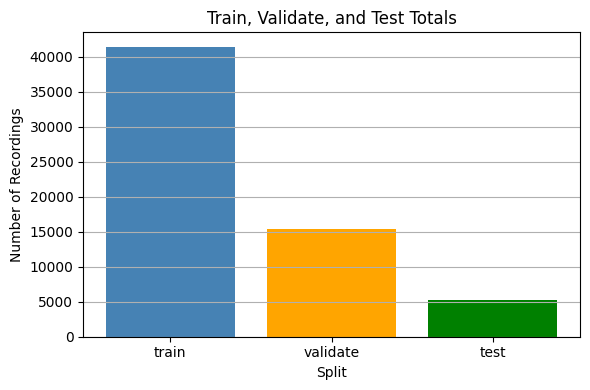

In [4]:
# ---------- ASSIGN AND PLOT SPLIT DATA ----------
train_df = annotations_df[annotations_df['split'] == 'train']
valid_df = annotations_df[annotations_df['split'] == 'validate']
test_df  = annotations_df[annotations_df['split'] == 'test']

# ---------- PRINT SENSOR SETS ----------
print("Train sensors   :", set(train_df['sensor_id']))
print("Validate sensors:", set(valid_df['sensor_id']))
print("Test sensors    :", set(test_df['sensor_id']))

# ---------- COUNT RECORDINGS PER SPLIT ----------
split_counts = annotations_df['split'].value_counts().reindex(
    ['train', 'validate', 'test'], fill_value=0
)

# ---------- PLOT RECORDINGS ----------
plt.figure(figsize=(6, 4))
colors = ['steelblue', 'orange', 'green']
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])

plt.title("Train, Validate, and Test Totals")
plt.xlabel("Split")
plt.ylabel("Number of Recordings")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

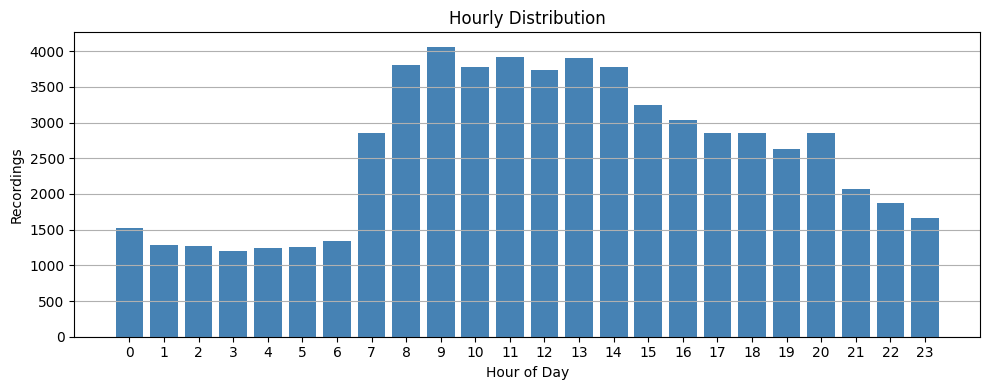

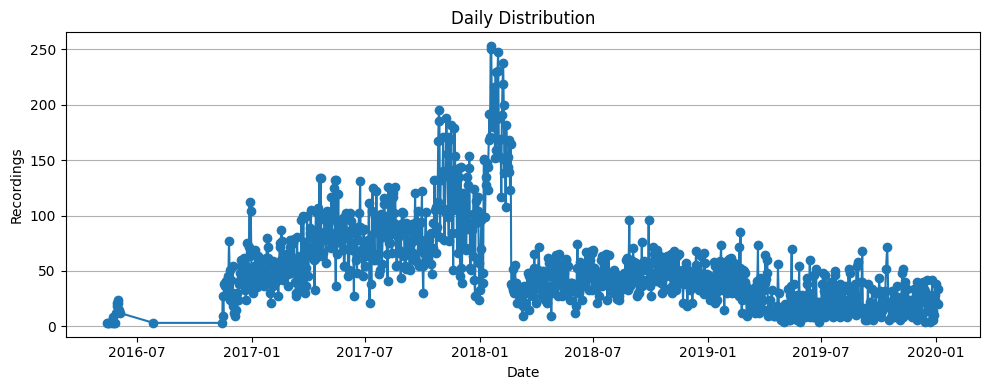

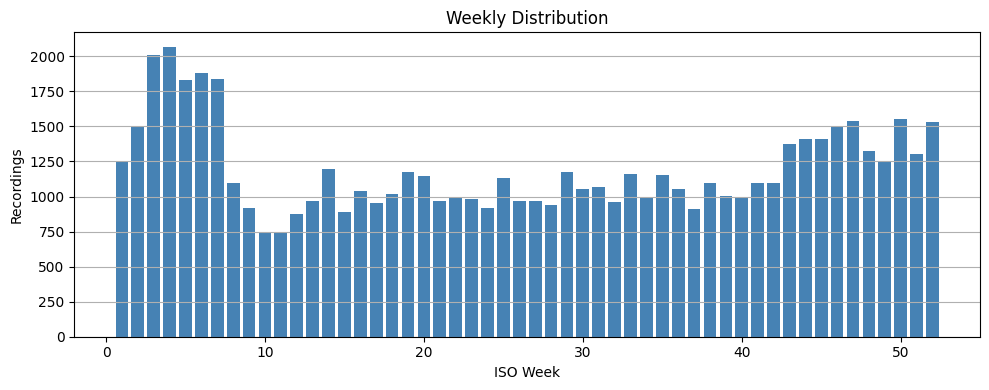

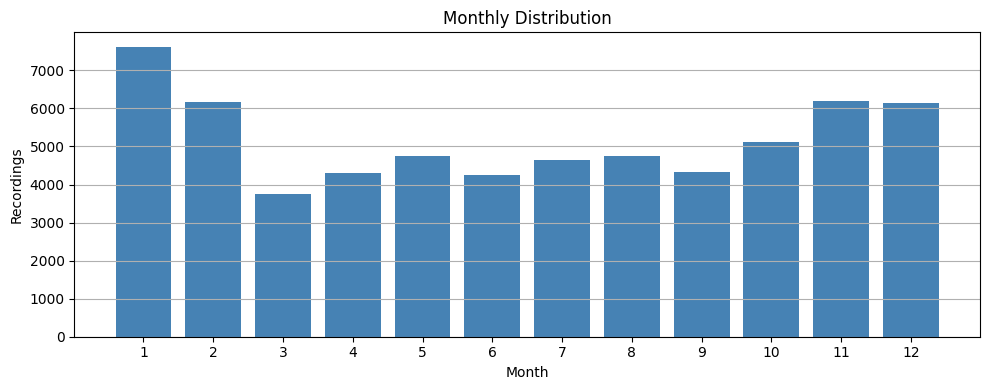

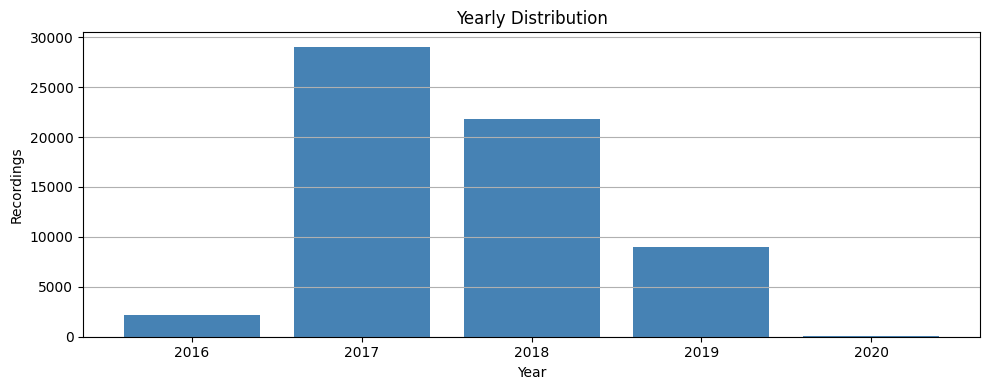

In [5]:
# ---------- COMPUTE AND PLOT TEMPORAL DATA (FULL DATASET) ----------

# Construct datetime column
annotations_df = u.construct_datetime(annotations_df)

# Plot overall time-based distributions
u.compute_and_plot_distributions(annotations_df)

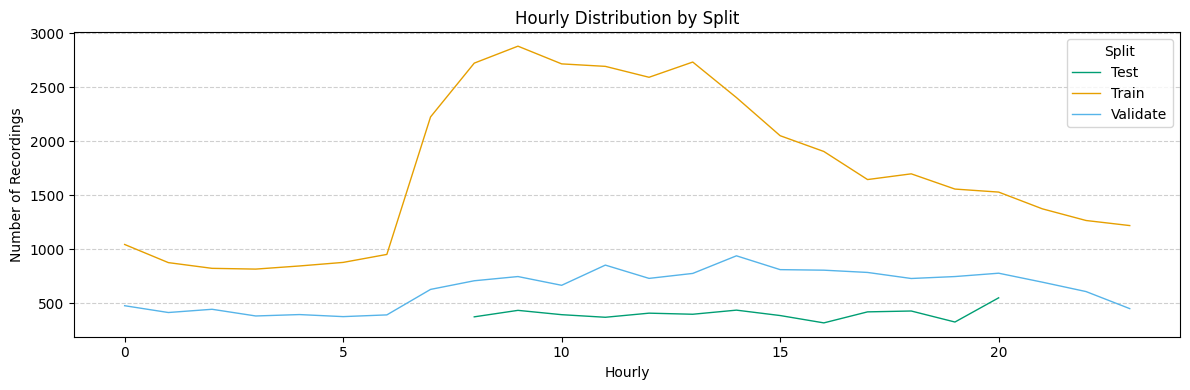

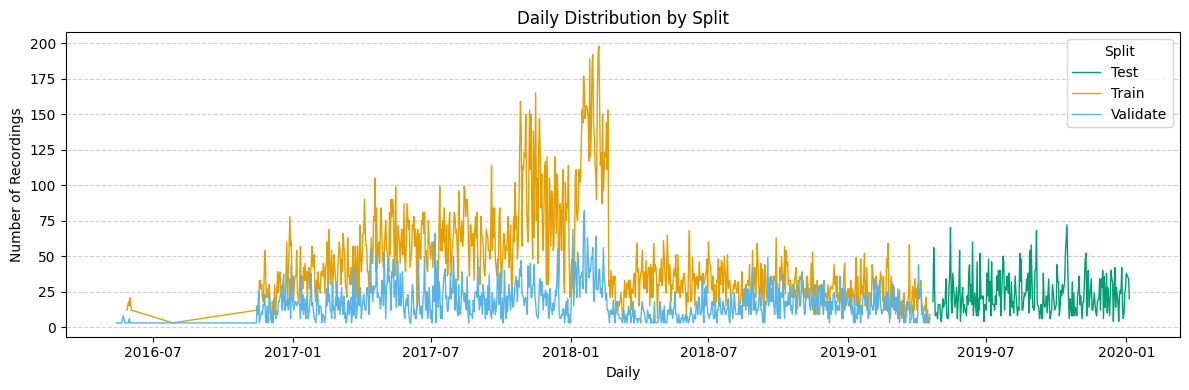

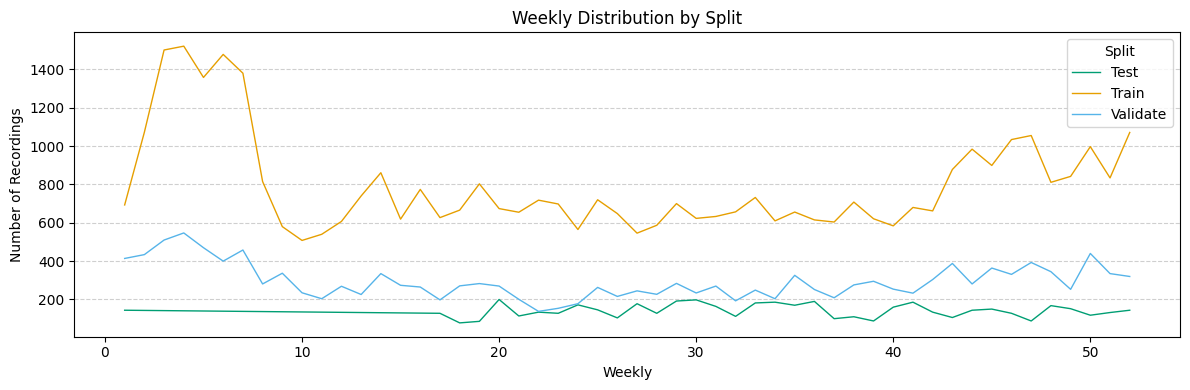

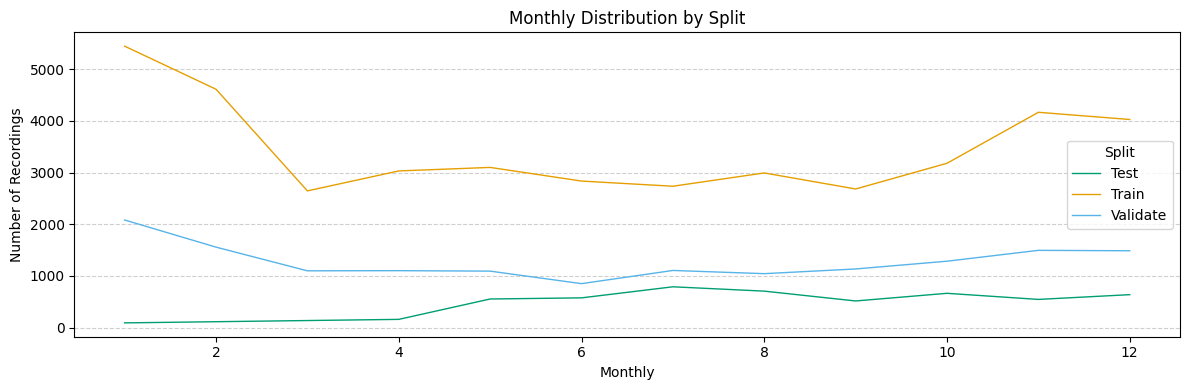

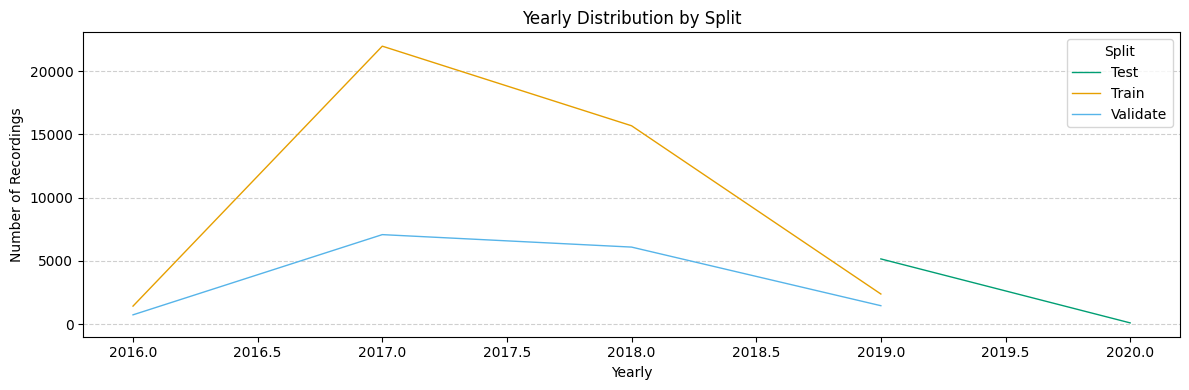

In [6]:
# ---------- COMPUTE AND PLOT TEMPORAL DATA (SPLIT) ----------
u.plot_distributions_by_split(annotations_df)

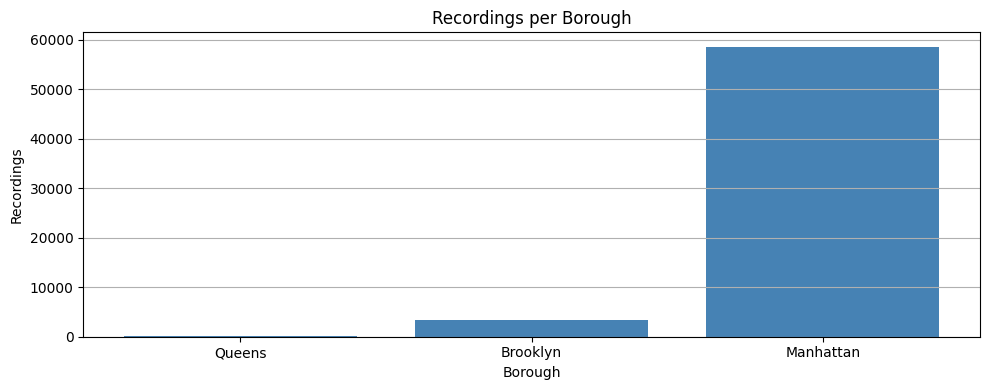

In [7]:
# ---------- Borough Mapping ----------
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

# Map borough ID to name
annotations_df['borough_name'] = annotations_df['borough'].map(borough_map)

# Count number of recordings per borough (with data)
borough_counts = annotations_df['borough_name'].value_counts().sort_index()

# Order from greatest to least
ordered_boroughs = [name for id_, name in borough_map.items() if name in borough_counts.index]
borough_counts = borough_counts[ordered_boroughs]
borough_counts = borough_counts.sort_values(ascending=True)

# ---------- Plot ----------
u.plot_distribution(
    borough_counts,
    xlabel="Borough",
    ylabel="Recordings",
    title="Recordings per Borough"
)

<ipython-input-8-d5cae62ea381>:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sensor_order[x['sensor_id'].iloc[0]] + len(x) / 2)


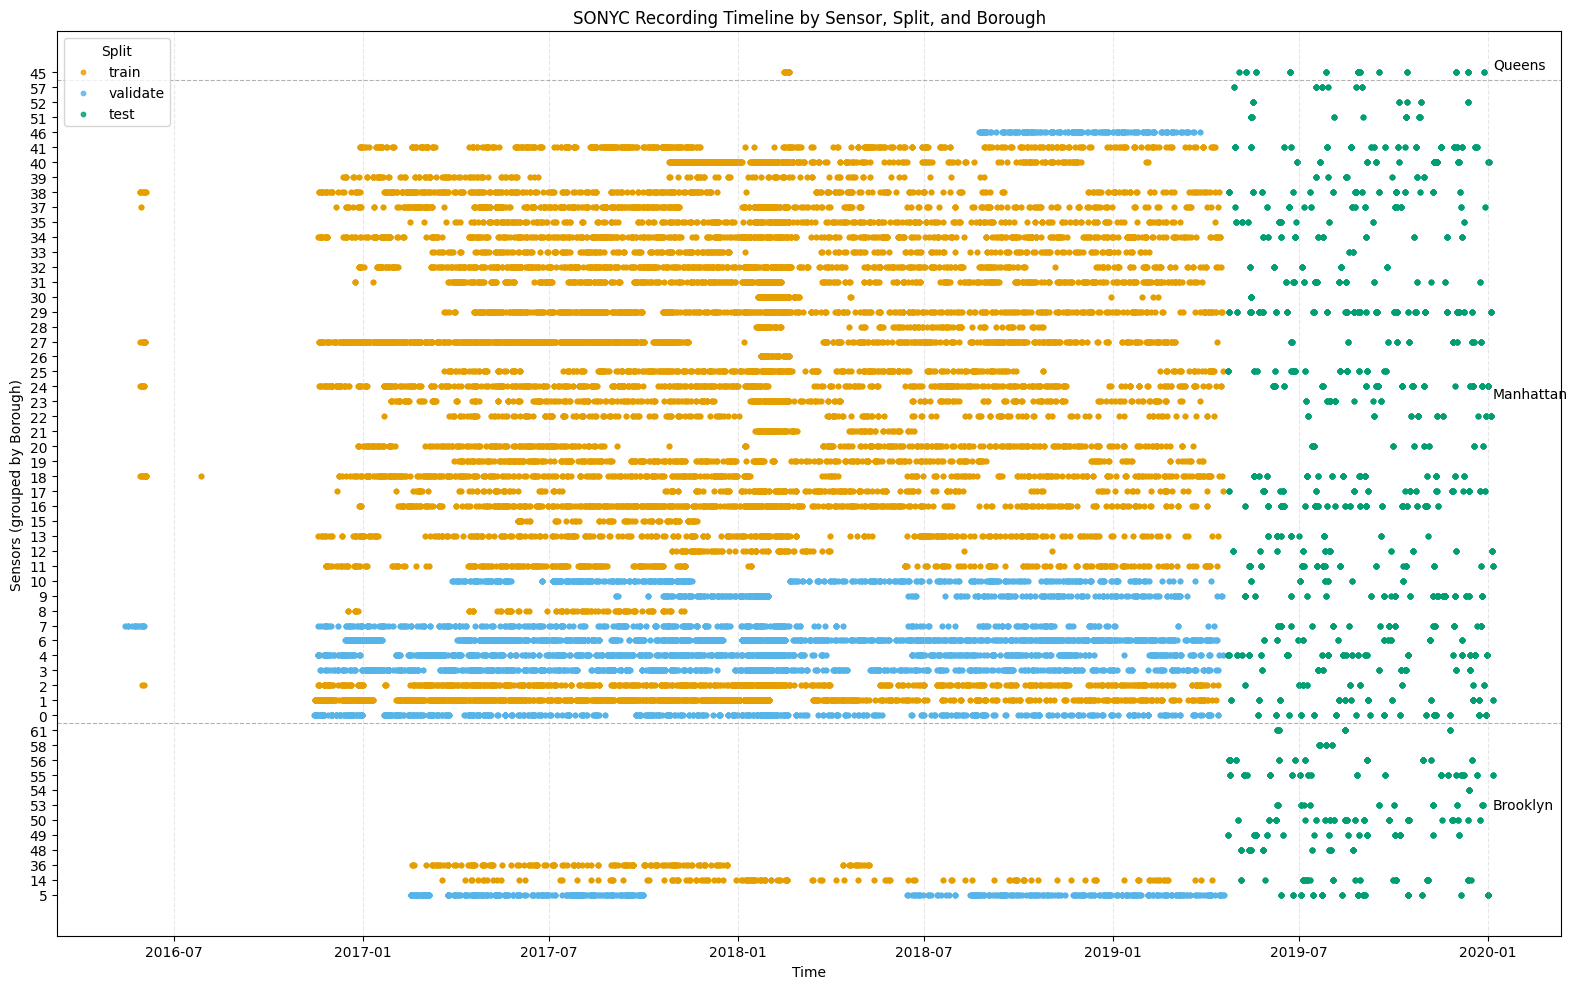

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- BOROUGH MAPPING ----------
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

annotations_df['borough_name'] = annotations_df['borough'].map(borough_map)

# ---------- ORDER SENSORS BY BOROUGH THEN SENSOR_ID ----------
ordered_sensors = (
    annotations_df[['sensor_id', 'borough_name']]
    .drop_duplicates()
    .sort_values(['borough_name', 'sensor_id'])
)

sensor_order = {sid: i for i, sid in enumerate(ordered_sensors['sensor_id'])}
annotations_df['sensor_y'] = annotations_df['sensor_id'].map(sensor_order)

# ---------- HIGH-CONTRAST SPLIT COLORS ----------
split_colors = {
    'train': '#E69F00',     # orange
    'validate': '#56B4E9',  # sky blue
    'test': '#009E73'       # teal
}

# ---------- RESET TO LIGHT BACKGROUND ----------
plt.style.use('default')

# ---------- BEGIN PLOTTING ----------
fig, ax = plt.subplots(figsize=(16, 10))

# ---------- PLOT RECORDING POINTS COLORED BY SPLIT ----------
for split, color in split_colors.items():
    subset = annotations_df[annotations_df['split'] == split]
    ax.scatter(
        subset['datetime'],
        subset['sensor_y'],
        s=10,
        color=color,
        alpha=0.8,
        label=split
    )

# ---------- DRAW BOROUGH SEPARATION LINES ----------
borough_boundaries = []
current_borough = None

for i, (_, row) in enumerate(ordered_sensors.iterrows()):
    borough = row['borough_name']
    if borough != current_borough:
        if i != 0:
            borough_boundaries.append(i - 0.5)
        current_borough = borough

for y in borough_boundaries:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# ---------- LABEL BOROUGHS ON RIGHT ----------
borough_labels = (
    ordered_sensors.groupby('borough_name')
    .apply(lambda x: sensor_order[x['sensor_id'].iloc[0]] + len(x) / 2)
)

for borough, y in borough_labels.items():
    ax.text(
        annotations_df['datetime'].max(),
        y,
        borough,
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

# ---------- AXIS AND TITLE ----------
ax.set_xlabel("Time")
ax.set_ylabel("Sensors (grouped by Borough)")
ax.set_title("SONYC Recording Timeline by Sensor, Split, and Borough")
ax.set_yticks(list(sensor_order.values()))
ax.set_yticklabels(list(sensor_order.keys()))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

# ---------- LEGEND ----------
ax.legend(title="Split", loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------

                         PLOT AND PLAYBACK AUDIO FILES                          

--------------------------------------------------------------------------------
Loaded audio file : /content/drive/MyDrive/dl4m/final-project/SONYC/audio/01_009953.wav
Waveform shape    : (1, 480000)
Sample rate       : 48000 Hz
--------------------------------------------------------------------------------


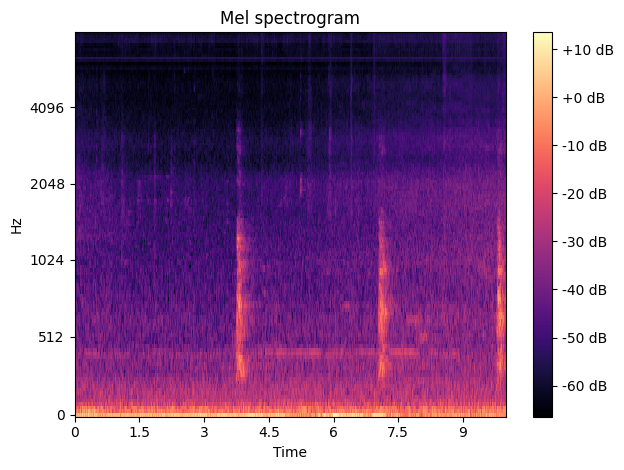

In [9]:
# ---------- PLOT AND PLAYBACK AUDIO FILES ----------

# ---------- SELECT RANDOM FILE ----------
example_audio = random.choice(audio_files)

# ---------- LOAD AUDIO DATA ----------
waveform, sample_rate = torchaudio.load(example_audio)
waveform = waveform.numpy()

# ---------- DISPLAY FILE INFO ----------
print("-" * 80)
title = "PLOT AND PLAYBACK AUDIO FILES"
print("\n" + title.center(80) + "\n")
print("-" * 80)
print(f"Loaded audio file : {example_audio}")
print(f"Waveform shape    : {waveform.shape}")
print(f"Sample rate       : {sample_rate} Hz")
print("-" * 80)

# ---------- PLOT MEL SPECTROGRAM ----------
u.compute_mel_spectrogram(
    waveform,
    sample_rate,
    n_mels=128,
    hop_length=512
)

# ---------- PLAY AUDIO ----------
ipd.Audio(example_audio)